<a href="https://colab.research.google.com/github/madhurapanvelkar20/AI_Traffic_Management/blob/main/CaseStudyProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All libraries imported successfully!
Dataset loaded!
Shape: (48204, 9)
   traffic_volume holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0            5545     NaN  288.28      0.0      0.0          40       Clouds   
1            4516     NaN  289.36      0.0      0.0          75       Clouds   
2            4767     NaN  289.58      0.0      0.0          90       Clouds   
3            5026     NaN  290.13      0.0      0.0          90       Clouds   
4            4918     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description         date_time  
0    scattered clouds  02-10-2012 09:00  
1       broken clouds  02-10-2012 10:00  
2     overcast clouds  02-10-2012 11:00  
3     overcast clouds  02-10-2012 12:00  
4       broken clouds  02-10-2012 13:00  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------     

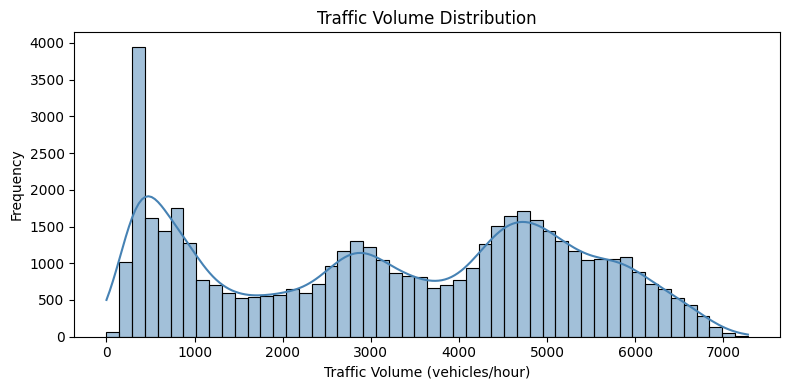

Plot saved!

Congestion Level Distribution:
congestion_level
High      20934
Low       15219
Medium    12051
Name: count, dtype: int64


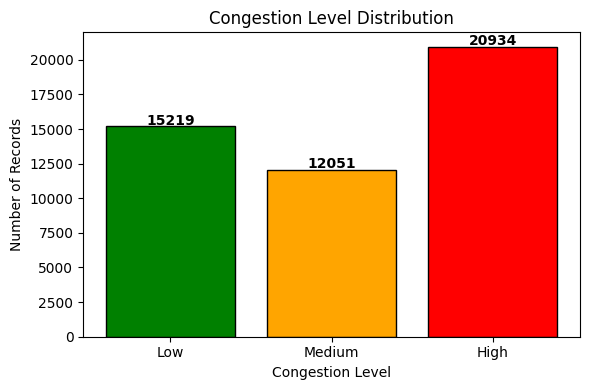

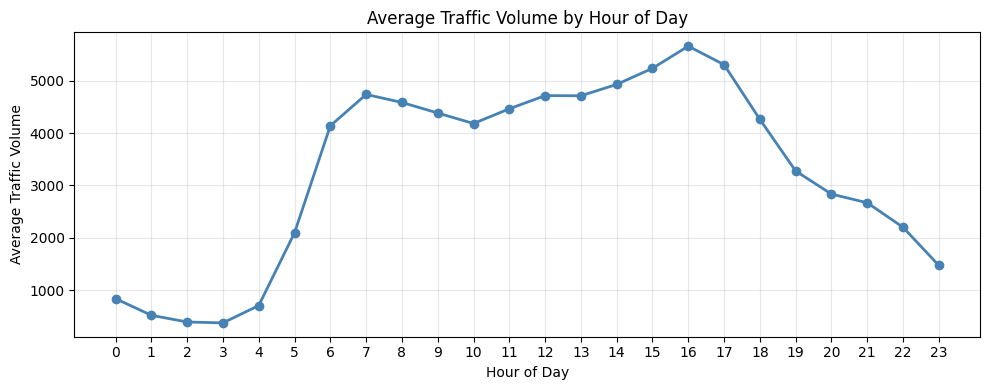

Label classes: ['High', 'Low', 'Medium']
Training samples : 38563
Testing  samples : 9641

=== Decision Tree ===
Accuracy: 92.10%
              precision    recall  f1-score   support

        High       0.93      0.96      0.94      4187
         Low       0.95      0.94      0.95      3044
      Medium       0.87      0.83      0.85      2410

    accuracy                           0.92      9641
   macro avg       0.92      0.91      0.91      9641
weighted avg       0.92      0.92      0.92      9641


=== Random Forest ===
Accuracy: 93.50%
              precision    recall  f1-score   support

        High       0.94      0.97      0.95      4187
         Low       0.96      0.95      0.96      3044
      Medium       0.89      0.86      0.87      2410

    accuracy                           0.93      9641
   macro avg       0.93      0.93      0.93      9641
weighted avg       0.93      0.93      0.93      9641



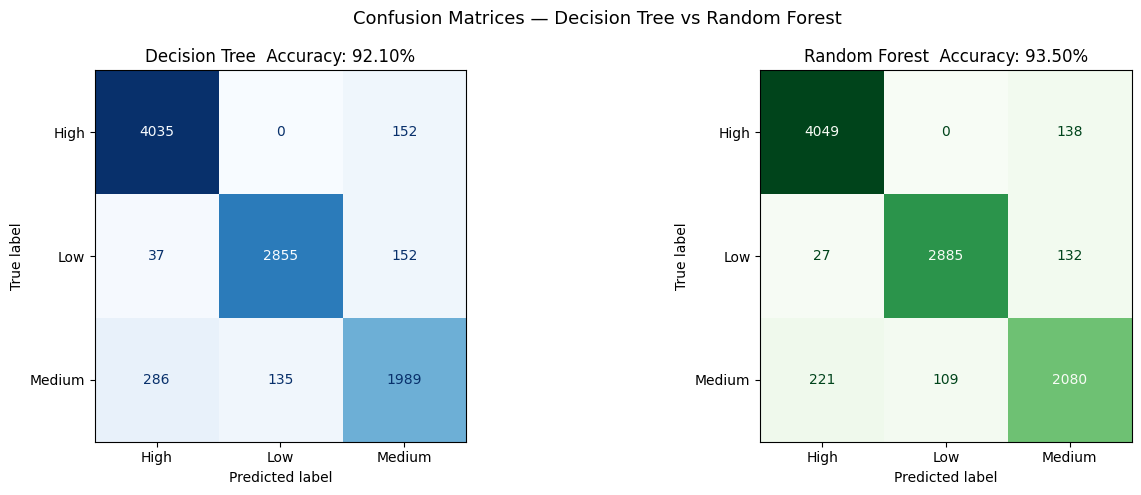

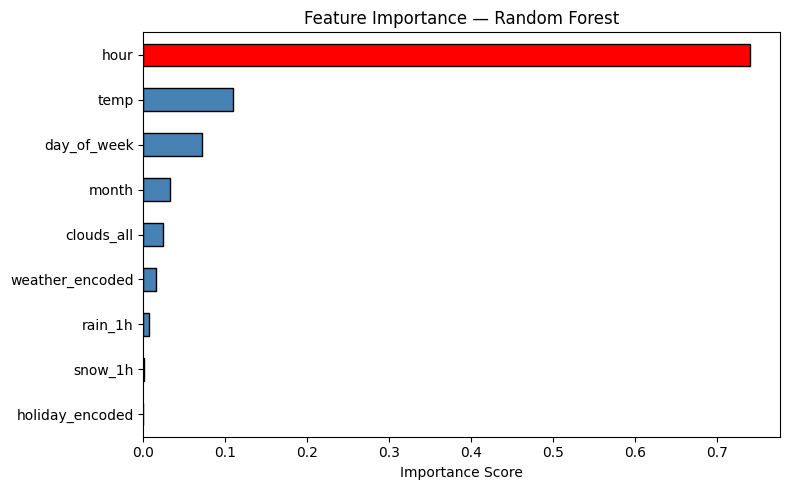


Top Features:
hour               0.739498
temp               0.109810
day_of_week        0.071500
month              0.031963
clouds_all         0.024340
weather_encoded    0.015674
rain_1h            0.006608
snow_1h            0.000439
holiday_encoded    0.000169
dtype: float64

         MODEL COMPARISON SUMMARY
  Decision Tree Accuracy : 92.10%
  Random Forest Accuracy : 93.50%
Random Forest outperforms Decision Tree
due to ensemble averaging of 100 trees.


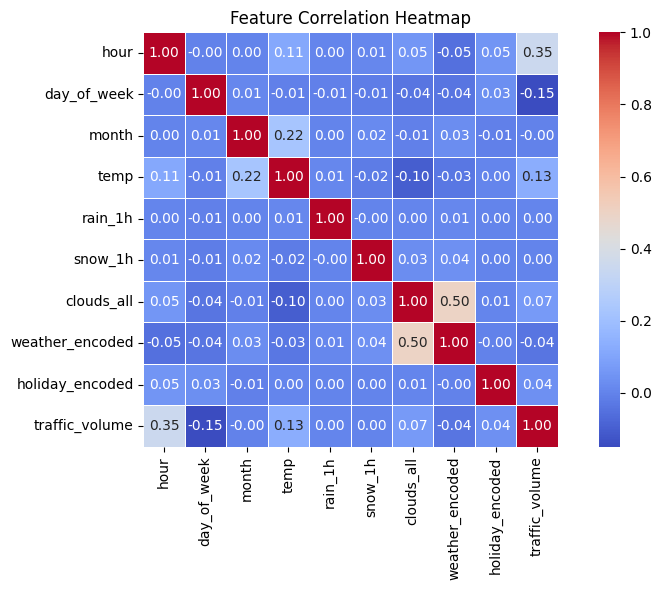

All agent tools defined!
TrafficAgent class defined!

--- Agent Episode Log (last 30 cycles) ---
 cycle  hour  label true_label  correct  confidence  phase  emergency
     1     7   High       High     True        1.00     90      False
     2     3    Low        Low     True        1.00     30      False
     3    17   High     Medium    False        0.72     90      False
     4    10   High       High     True        1.00     90      False
     5     6    Low        Low     True        1.00     30      False
     6     4    Low        Low     True        0.99     30      False
     7    23    Low        Low     True        1.00     30      False
     8    18   High       High     True        0.98     90      False
     9    20 Medium     Medium     True        1.00    120       True
    10     3    Low        Low     True        1.00     30      False
    11    19 Medium     Medium     True        1.00     60      False
    12    18   High       High     True        0.92     90     

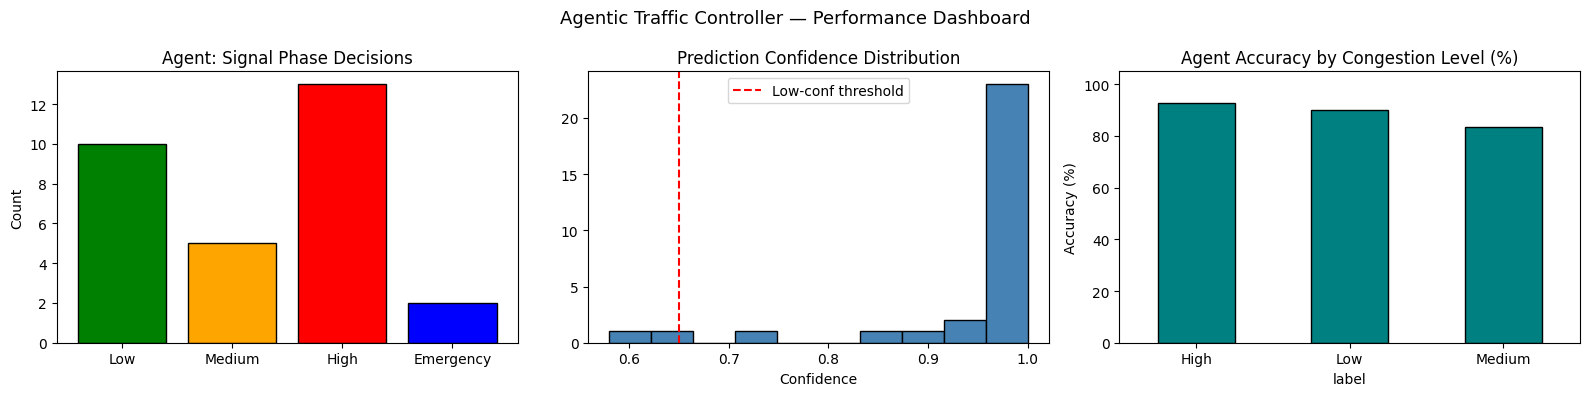

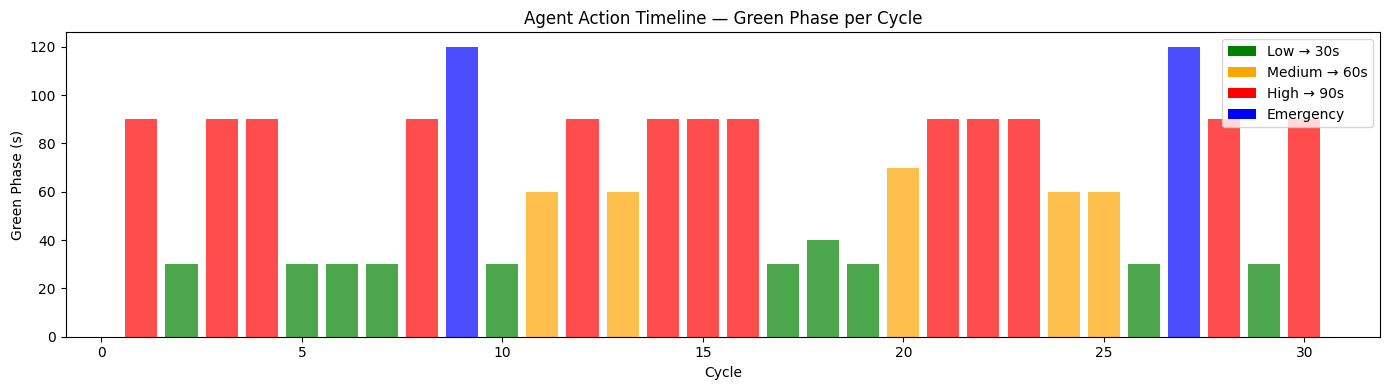

In [ ]:
# ============================================================
# AI-Based AGENTIC Autonomous Traffic Management System
# ============================================================

# ── Install & Import Libraries ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random
import logging
from collections import deque
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

logging.basicConfig(level=logging.INFO, format='[%(asctime)s] %(levelname)s: %(message)s',
                    datefmt='%H:%M:%S')
logger = logging.getLogger("TrafficAgent")

print("All libraries imported successfully!")

# ── Load Dataset ─────────────────────────────────────
df = pd.read_csv('Metro_Interstate_Traffic_Volume (1).csv')

print("Dataset loaded!")
print("Shape:", df.shape)
print(df.head())


# ── Basic EDA ────────────────────────────────────────
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Traffic Volume Stats ---")
print(df['traffic_volume'].describe())


# ── Traffic Volume Distribution Plot ─────────────────
plt.figure(figsize=(8, 4))
sns.histplot(df['traffic_volume'], bins=50, kde=True, color='steelblue')
plt.title('Traffic Volume Distribution')
plt.xlabel('Traffic Volume (vehicles/hour)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('traffic_volume_distribution.png', dpi=150)
plt.show()
print("Plot saved!")


# ── Feature Engineering ──────────────────────────────
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month']       = df['date_time'].dt.month

def label_congestion(vol):
    if vol < 2000:   return 'Low'
    elif vol <= 4000: return 'Medium'
    else:             return 'High'

df['congestion_level'] = df['traffic_volume'].apply(label_congestion)
print("\nCongestion Level Distribution:")
print(df['congestion_level'].value_counts())


# ── Congestion Level Bar Chart ───────────────────────
plt.figure(figsize=(6, 4))
order  = ['Low', 'Medium', 'High']
colors = ['green', 'orange', 'red']
counts = df['congestion_level'].value_counts()[order]
plt.bar(order, counts, color=colors, edgecolor='black')
plt.title('Congestion Level Distribution')
plt.xlabel('Congestion Level')
plt.ylabel('Number of Records')
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('congestion_distribution.png', dpi=150)
plt.show()


# ── Hourly Traffic Pattern ───────────────────────────
plt.figure(figsize=(10, 4))
hourly_avg = df.groupby('hour')['traffic_volume'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue', linewidth=2)
plt.title('Average Traffic Volume by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Traffic Volume')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hourly_traffic_pattern.png', dpi=150)
plt.show()


# ──Encode Categorical Variables ─────────────────────
le_weather  = LabelEncoder()
le_holiday  = LabelEncoder()
le_target   = LabelEncoder()

df['weather_encoded']    = le_weather.fit_transform(df['weather_main'])
df['holiday_encoded']    = le_holiday.fit_transform(df['holiday'])
df['congestion_encoded'] = le_target.fit_transform(df['congestion_level'])
print("Label classes:", list(le_target.classes_))


# ──Prepare Features & Split Data ────────────────────
FEATURES = ['hour', 'day_of_week', 'month',
            'temp', 'rain_1h', 'snow_1h', 'clouds_all',
            'weather_encoded', 'holiday_encoded']

X = df[FEATURES]
y = df['congestion_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


# ── Train Decision Tree ─────────────────────────────
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred  = dt_model.predict(X_test)
dt_acc   = accuracy_score(y_test, dt_pred)

print(f"\n=== Decision Tree ===")
print(f"Accuracy: {dt_acc * 100:.2f}%")
print(classification_report(y_test, dt_pred, target_names=le_target.classes_))


# ── Train Random Forest ─────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_pred)

print(f"\n=== Random Forest ===")
print(f"Accuracy: {rf_acc * 100:.2f}%")
print(classification_report(y_test, rf_pred, target_names=le_target.classes_))


# ── Confusion Matrices ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt   = confusion_matrix(y_test, dt_pred)
disp_dt = ConfusionMatrixDisplay(cm_dt, display_labels=le_target.classes_)
disp_dt.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Decision Tree  Accuracy: {dt_acc*100:.2f}%')

cm_rf   = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=le_target.classes_)
disp_rf.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Random Forest  Accuracy: {rf_acc*100:.2f}%')

plt.suptitle('Confusion Matrices — Decision Tree vs Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()


# ── Feature Importance ──────────────────────────────
feat_importance = pd.Series(rf_model.feature_importances_, index=FEATURES)
feat_importance = feat_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors_bar = ['red' if x > 0.15 else 'steelblue' for x in feat_importance]
feat_importance.plot(kind='barh', color=colors_bar, edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("\nTop Features:")
print(feat_importance.sort_values(ascending=False))


# ── Model Comparison Summary ────────────────────────
print("\n" + "="*45)
print("         MODEL COMPARISON SUMMARY")
print("="*45)
print(f"  Decision Tree Accuracy : {dt_acc * 100:.2f}%")
print(f"  Random Forest Accuracy : {rf_acc * 100:.2f}%")
print("="*45)
print("Random Forest outperforms Decision Tree")
print("due to ensemble averaging of 100 trees.")


# ── Correlation Heatmap ─────────────────────────────
plt.figure(figsize=(9, 6))
corr = df[FEATURES + ['traffic_volume']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
# ── Agent Tools ─────────────────────────────────────

def sensor_tool(df_pool, n=1):
    """
    Tool: read_sensors
    Simulates real-time sensor data by sampling rows from the
    historical dataset.  In a real deployment this would call
    loop-detector / weather-API endpoints.
    Returns a list of dicts, one per reading.
    """
    sample = df_pool.sample(n)
    readings = []
    for _, row in sample.iterrows():
        readings.append({
            'hour':            row['hour'],
            'day_of_week':     row['day_of_week'],
            'month':           row['month'],
            'temp':            row['temp'],
            'rain_1h':         row['rain_1h'],
            'snow_1h':         row['snow_1h'],
            'clouds_all':      row['clouds_all'],
            'weather_encoded': row['weather_encoded'],
            'holiday_encoded': row['holiday_encoded'],
            'true_volume':     row['traffic_volume'],   # for eval only
        })
    return readings


def emergency_tool():
    """
    Tool: emergency_vehicle_check
    Simulates acoustic / GPS emergency transponder detection.
    Returns True 5% of the time (configurable via EMERGENCY_RATE).
    In production: interface with V2I or CAD dispatch system.
    """
    EMERGENCY_RATE = 0.05
    detected = random.random() < EMERGENCY_RATE
    return {'emergency_detected': detected}


def signal_actuator(phase_seconds, reason, intersection_id='INT-001'):
    """
    Tool: actuate_signal
    Applies hard safety bounds then records the actuation.
    Returns the final applied phase.
    Safety bounds:
        MIN_GREEN          = 10 s  (prevent mid-intersection trap)
        PEDESTRIAN_MIN     = 15 s  (accessibility requirement)
        MAX_GREEN          = 120 s (avoid starvation on cross-road)
    """
    MIN_GREEN      = 10
    PEDESTRIAN_MIN = 15
    MAX_GREEN      = 120

    phase = max(phase_seconds, MIN_GREEN)
    phase = max(phase, PEDESTRIAN_MIN)
    phase = min(phase, MAX_GREEN)

    record = {
        'intersection_id':  intersection_id,
        'requested_phase':  phase_seconds,
        'applied_phase':    phase,
        'reason':           reason,
        'timestamp':        datetime.now().strftime('%H:%M:%S'),
    }
    return record


def retraining_tool(model, X_new, y_new):
    """
    Tool: retrain_model
    Incrementally updates the Random Forest by appending new data
    and retraining.  Returns the updated model and new accuracy.
    This implements a basic online-adaptation loop — a key
    characteristic of autonomous agentic systems.
    """
    logger.info(f"[RETRAIN] Retraining on {len(X_new)} new samples ...")
    model.fit(X_new, y_new)
    acc = accuracy_score(y_new, model.predict(X_new))
    logger.info(f"[RETRAIN] Complete. In-sample accuracy: {acc*100:.2f}%")
    return model, acc


def anomaly_detector(reading, df_pool, z_thresh=3.0):
    """
    Tool: detect_anomaly
    Flags sensor readings that are statistically anomalous
    (Z-score > z_thresh) on any numeric feature.
    Returns a dict: {feature: z_score} for flagged features.
    """
    numeric_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']
    flagged = {}
    for f in numeric_features:
        mean = df_pool[f].mean()
        std  = df_pool[f].std() + 1e-9
        z    = abs((reading[f] - mean) / std)
        if z > z_thresh:
            flagged[f] = round(z, 2)
    return flagged


print("All agent tools defined!")


# ── Agent Memory ────────────────────────────────────
class AgentMemory:
    """
    Short-term working memory for the agent.
    Stores recent perception-action episodes and tracks
    performance metrics over a rolling window.
    """
    def __init__(self, maxlen=50):
        self.episodes     = deque(maxlen=maxlen)   # recent cycles
        self.action_log   = []                      # full action history
        self.retrain_log  = []                      # retraining events
        self.anomaly_log  = []                      # anomaly events
        self.phase_counts = {'Low': 0, 'Medium': 0, 'High': 0, 'Emergency': 0}

    def record_episode(self, ep):
        self.episodes.append(ep)
        self.action_log.append(ep)
        label = ep.get('label', 'Low')
        if ep.get('emergency'):
            self.phase_counts['Emergency'] += 1
        else:
            self.phase_counts[label] = self.phase_counts.get(label, 0) + 1

    def recent_accuracy(self):
        """Fraction of recent episodes where prediction matched true label."""
        recent = [e for e in self.episodes if 'true_label' in e]
        if not recent:
            return None
        correct = sum(1 for e in recent
                      if e['label'] == e.get('true_label'))
        return correct / len(recent)

    def summary(self):
        acc = self.recent_accuracy()
        return {
            'total_cycles':   len(self.action_log),
            'phase_counts':   dict(self.phase_counts),
            'recent_accuracy': f"{acc*100:.1f}%" if acc else "N/A",
            'retraining_events': len(self.retrain_log),
            'anomalies_detected': len(self.anomaly_log),
        }


# ── TrafficAgent Class ──────────────────────────────
class TrafficAgent:
    """
    Agentic AI Traffic Signal Controller
    ======================================
    Implements the Perceive → Reason → Plan → Act → Reflect cycle.

    Key agentic properties:
      • Autonomy        — runs in a closed loop without human input
      • Tool use        — calls sensor, actuator, emergency, anomaly tools
      • Memory          — maintains episode history and performance stats
      • Goal-directedness — targets minimum wait time, maximises throughput
      • Self-reflection  — monitors accuracy drift, triggers retraining
      • Adaptability    — retrains on new data when drift is detected
    """

    # ── Signal timing map ──
    PHASE_MAP = {'High': 90, 'Medium': 60, 'Low': 30}

    # ── Propositional logic rules ─────────────
    PEAK_HOURS   = set(range(7, 10)) | set(range(16, 19))
    OFF_HOURS    = set(range(0, 6))
    WEEKEND_DAYS = {5, 6}

    # ── Agent goals ─────────────────────────────────────────────
    GOALS = {
        'min_wait_time':     True,
        'max_throughput':    True,
        'reduce_emissions':  True,
        'emergency_priority': True,
    }

    # ── Drift threshold: retrain if rolling accuracy < this ─────
    DRIFT_THRESHOLD = 0.80
    RETRAIN_WINDOW  = 20   # episodes before evaluating accuracy

    def __init__(self, model, label_encoder, feature_names, df_pool):
        self.model         = model
        self.le_target     = label_encoder
        self.feature_names = feature_names
        self.df_pool       = df_pool
        self.memory        = AgentMemory()
        self.cycle_count   = 0
        self.state         = 'IDLE'   # agent lifecycle state
        logger.info("TrafficAgent initialised. Goals: %s", list(self.GOALS.keys()))

    # ── Tool dispatcher ─────────────────────────────────────────
    def tool_call(self, tool_name, **kwargs):
        """
        Central tool dispatcher.
        Mirrors the function-calling interface used by agentic LLM systems.
        """
        tools = {
            'read_sensors':          lambda: sensor_tool(self.df_pool),
            'check_emergency':       lambda: emergency_tool(),
            'actuate_signal':        lambda: signal_actuator(**kwargs),
            'retrain_model':         lambda: retraining_tool(**kwargs),
            'detect_anomaly':        lambda: anomaly_detector(**kwargs),
        }
        if tool_name not in tools:
            raise ValueError(f"Unknown tool: {tool_name}")
        return tools[tool_name]()

    # ── Step 1: PERCEIVE ────────────────────────────────────────
    def perceive(self):
        """Read sensor data and check for emergency vehicles."""
        readings  = self.tool_call('read_sensors')
        emergency = self.tool_call('check_emergency')
        return readings[0], emergency['emergency_detected']

    # ── Step 2: REASON ──────────────────────────────────────────
    def reason(self, reading):
        """
        Classify congestion using:
          (a) ML model prediction (primary)
          (b) Propositional logic rules (override / validation)
        Returns predicted label, confidence, and rule override flag.
        """
        # Build feature vector
        X_input = pd.DataFrame([{f: reading[f] for f in self.feature_names}])

        # ML prediction with probability
        proba  = self.model.predict_proba(X_input)[0]
        label_enc = self.model.predict(X_input)[0]
        label  = self.le_target.inverse_transform([label_enc])[0]
        conf   = round(float(max(proba)), 3)

        # Anomaly check
        anomalies = self.tool_call('detect_anomaly',
                                   reading=reading, df_pool=self.df_pool)
        if anomalies:
            self.memory.anomaly_log.append({'cycle': self.cycle_count,
                                             'features': anomalies})
            logger.warning("[ANOMALY] Detected in features: %s", anomalies)

        # Rule-based overrides (CO3 propositional logic from report)
        rule_override = None
        h   = reading['hour']
        dow = reading['day_of_week']

        if h in self.PEAK_HOURS and dow not in self.WEEKEND_DAYS:
            rule_override = 'High'   # Rule 1: peak hour
        elif (h in self.OFF_HOURS) or (dow in self.WEEKEND_DAYS):
            rule_override = 'Low'    # Rule 3: off-peak

        # If confidence is low, defer to rule override if available
        final_label = label
        if conf < 0.60 and rule_override:
            final_label = rule_override
            logger.info("[REASON] Low confidence (%.2f) — rule override: %s → %s",
                        conf, label, rule_override)

        return final_label, conf, rule_override, anomalies

    # ── Step 3: PLAN ────────────────────────────────────────────
    def plan(self, label, confidence, emergency):
        """
        Goal-directed planning:
          - Emergency? → grant green immediately (Rule 4 hard interrupt)
          - Otherwise  → map label to phase, adjust for confidence
        Returns (phase_seconds, reason_string).
        """
        if emergency:
            return 999, "EMERGENCY_OVERRIDE"   # sentinel; actuator caps it

        base_phase = self.PHASE_MAP[label]

        # Adjust phase upward if confidence is low (conservative strategy)
        if confidence < 0.65:
            adjusted = min(base_phase + 10, 120)
            reason   = f"ML:{label} conf={confidence:.2f} low→+10s buffer"
        else:
            adjusted = base_phase
            reason   = f"ML:{label} conf={confidence:.2f}"

        return adjusted, reason

    # ── Step 4: ACT ─────────────────────────────────────────────
    def act(self, phase_seconds, reason):
        """Invoke signal actuator tool and log the actuation."""
        result = self.tool_call('actuate_signal',
                                phase_seconds=phase_seconds,
                                reason=reason)
        return result

    # ── Step 5: REFLECT ─────────────────────────────────────────
    def reflect(self, reading, label, conf, actuation, emergency):
        """
        Self-evaluation after each cycle:
          - Derive true label from sensor volume for comparison
          - Record episode in memory
          - Check accuracy drift → trigger retraining if needed
        """
        true_label = label_congestion(reading['true_volume'])
        correct    = (label == true_label) or emergency

        episode = {
            'cycle':       self.cycle_count,
            'hour':        reading['hour'],
            'label':       label,
            'true_label':  true_label,
            'correct':     correct,
            'confidence':  conf,
            'phase':       actuation['applied_phase'],
            'emergency':   emergency,
            'timestamp':   actuation['timestamp'],
        }
        self.memory.record_episode(episode)

        # Accuracy drift detection
        if self.cycle_count > 0 and self.cycle_count % self.RETRAIN_WINDOW == 0:
            acc = self.memory.recent_accuracy()
            logger.info("[REFLECT] Rolling accuracy over last %d cycles: %.1f%%",
                        self.RETRAIN_WINDOW, acc * 100 if acc else 0)
            if acc is not None and acc < self.DRIFT_THRESHOLD:
                logger.warning("[REFLECT] Accuracy drift detected (%.1f%% < %.0f%%). "
                               "Triggering retraining ...", acc * 100,
                               self.DRIFT_THRESHOLD * 100)
                self._retrain()

        return episode

    # ── Retraining sub-routine ───────────────────────────────────
    def _retrain(self):
        """Retrain the model on a fresh 20% sample of the pool."""
        sample   = self.df_pool.sample(frac=0.20, random_state=self.cycle_count)
        X_new    = sample[self.feature_names]
        y_new    = self.le_target.transform(
                       sample['traffic_volume'].apply(label_congestion))
        self.model, new_acc = self.tool_call('retrain_model',
                                              model=self.model,
                                              X_new=X_new, y_new=y_new)
        self.memory.retrain_log.append({
            'cycle':    self.cycle_count,
            'accuracy': new_acc,
        })

    # ── Main autonomous loop ─────────────────────────────────────
    def run(self, n_cycles=10, delay=0.0):
        """
        Run the agent for n_cycles autonomous perception-action loops.
        Set delay > 0 to simulate real-time operation (seconds per cycle).
        """
        self.state = 'RUNNING'
        logger.info("="*55)
        logger.info("TrafficAgent STARTED  |  %d cycles planned", n_cycles)
        logger.info("="*55)

        for _ in range(n_cycles):
            self.cycle_count += 1

            # ── Perceive ──
            reading, emergency = self.perceive()

            # ── Reason ──
            label, conf, rule_override, anomalies = self.reason(reading)

            # ── Plan ──
            phase, reason_str = self.plan(label, conf, emergency)

            # ── Act ──
            actuation = self.act(phase, reason_str)

            # ── Reflect ──
            episode = self.reflect(reading, label, conf, actuation, emergency)

            # ── Log cycle summary ──
            status = "EMERGENCY" if emergency else f"[{label:<6}]"
            logger.info(
                "Cycle %03d %s  hour=%-2d  conf=%.2f  phase=%2ds  correct=%s%s",
                self.cycle_count, status,
                reading['hour'], conf,
                actuation['applied_phase'],
                "✓" if episode['correct'] else "✗",
                f"  anomaly={anomalies}" if anomalies else ""
            )

            if delay > 0:
                time.sleep(delay)

        self.state = 'IDLE'
        logger.info("="*55)
        logger.info("TrafficAgent STOPPED")
        summary = self.memory.summary()
        for k, v in summary.items():
            logger.info("  %-24s: %s", k, v)
        logger.info("="*55)
        return self.memory


print("TrafficAgent class defined!")


# ── Instantiate & Run the Agent ─────────────────────
agent = TrafficAgent(
    model         = rf_model,
    label_encoder = le_target,
    feature_names = FEATURES,
    df_pool       = df
)

# Run 30 autonomous cycles (set delay=1.0 to simulate real-time)
memory = agent.run(n_cycles=30, delay=0.0)


# ── Agent Performance Dashboard ─────────────────────
episodes_df = pd.DataFrame(list(memory.episodes))
print("\n--- Agent Episode Log (last 30 cycles) ---")
print(episodes_df[['cycle', 'hour', 'label', 'true_label',
                    'correct', 'confidence', 'phase', 'emergency']].to_string(index=False))


# ── Agent Visualisation — Phase Distribution ────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Phase counts
labels_order = ['Low', 'Medium', 'High']
counts_agent = [memory.phase_counts.get(l, 0) for l in labels_order + ['Emergency']]
axes[0].bar(labels_order + ['Emergency'],
            counts_agent,
            color=['green', 'orange', 'red', 'blue'],
            edgecolor='black')
axes[0].set_title('Agent: Signal Phase Decisions')
axes[0].set_ylabel('Count')

# Confidence distribution
axes[1].hist(episodes_df['confidence'], bins=10, color='steelblue', edgecolor='black')
axes[1].axvline(0.65, color='red', linestyle='--', label='Low-conf threshold')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].set_xlabel('Confidence')
axes[1].legend()

# Correct vs incorrect per label
if not episodes_df.empty:
    corr = episodes_df.groupby('label')['correct'].mean() * 100
    corr.plot(kind='bar', ax=axes[2], color='teal', edgecolor='black')
    axes[2].set_title('Agent Accuracy by Congestion Level (%)')
    axes[2].set_ylabel('Accuracy (%)')
    axes[2].set_ylim(0, 105)
    axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Agentic Traffic Controller — Performance Dashboard', fontsize=13)
plt.tight_layout()
plt.savefig('agent_performance_dashboard.png', dpi=150)
plt.show()


# ── Agent Timeline ───────────────────────────────────
if not episodes_df.empty:
    fig, ax = plt.subplots(figsize=(14, 4))
    color_map = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
    for _, ep in episodes_df.iterrows():
        col = 'blue' if ep['emergency'] else color_map.get(ep['label'], 'gray')
        ax.bar(ep['cycle'], ep['phase'], color=col, alpha=0.7, width=0.8)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Green Phase (s)')
    ax.set_title('Agent Action Timeline — Green Phase per Cycle')
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green',  label='Low → 30s'),
                       Patch(facecolor='orange', label='Medium → 60s'),
                       Patch(facecolor='red',    label='High → 90s'),
                       Patch(facecolor='blue',   label='Emergency')]
    ax.legend(handles=legend_elements, loc='upper right')
    plt.tight_layout()
    plt.savefig('agent_action_timeline.png', dpi=150)
    plt.show()
